# Goal: To predict the median house value of a census block group in California.

## One row in the dataset = one geographic region

## Target = median value of houses in that region

# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing  ## Data set
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from scipy.stats import skew

# 2. Load Dataset

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Meta data
MedInc → Median household income (in tens of thousands of dollars) in the census block group.

HouseAge → Median age (in years) of houses in the block group.

AveRooms → Average number of rooms per household in the block group.

AveBedrms → Average number of bedrooms per household in the block group.

Population → Total population living in the block group.

AveOccup → Average number of people per household in the block group.

Latitude → Geographic north–south coordinate of the block group.

Longitude → Geographic east–west coordinate of the block group.

MedHouseVal → Median house value (in hundreds of thousands of dollars) in the block group (target variable).

#### All columns are Continuous Numeric

In [3]:
df.shape

(20640, 9)

In [4]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

## Target:

In [5]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

## 3. Train–Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
                                                      X, y, test_size=0.2, random_state=42  ## Test data 20%
                                                   )

# 4. Baseline Model (No Feature Engineering)
## Linear Regression

In [7]:
lin_base = LinearRegression()
lin_base.fit(X_train, y_train)

y_pred_base = lin_base.predict(X_test)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

print("Baseline Linear RMSE:", rmse_base)
print("Baseline Linear R2:", r2_base)

Baseline Linear RMSE: 0.7455813830127764
Baseline Linear R2: 0.5757877060324508


#
RMSE = sqrt( (1/n) * Σ (yi − ŷi)^2 )

yi = actual value, ŷi = predicted value, n = number of observations

Lower RMSE indicates better model performance.
###

R-Squared =  1 − [ Σ (yi − ŷi)^2 / Σ (yi − ȳ)^2 ]

Higher R² indicates better fit.
#

## Knn Regressor (No Scaling)

In [9]:
knn_base = KNeighborsRegressor(n_neighbors=5)
knn_base.fit(X_train, y_train)

y_pred_knn_base = knn_base.predict(X_test)

rmse_knn_base = np.sqrt(mean_squared_error(y_test, y_pred_knn_base))
print("Baseline KNN RMSE:", rmse_knn_base)

Baseline KNN RMSE: 1.0576778270706204


# 5. Feature Distribution Analysis
## Check Skewness

In [10]:
skewness = X_train.apply(skew).sort_values(ascending=False)
skewness

,0
AveOccup,88.044664
AveBedrms,23.168641
AveRooms,18.605400
Population,5.275652
MedInc,1.633941
Latitude,0.461462
HouseAge,0.063448
Longitude,-0.288392


## Identify skewed features:
Skewness = 0 → perfectly symmetric

Skewness > 0 → right-skewed (long right tail)

Skewness < 0 → left-skewed (long left tail)


##
##

Skewness Value	        Interpretation:

Between -0.5 and 0.5	→ Approximately symmetric

Between 0.5 and 1	→ Moderately skewed

Greater than 1	→ Highly skewed

Less than -1	→ Highly left-skewed

If skewness > 1, it indicates strong right skewness (not a strict mathematical threshold).

In [11]:
skewed_features = skewness[skewness > 1].index.tolist()
skewed_features

['AveOccup', 'AveBedrms', 'AveRooms', 'Population', 'MedInc']

In [12]:
X_train['MedInc'].describe()

,MedInc
count,16512.000000
mean,3.880754
std,1.904294
min,0.499900
25%,2.566700
50%,3.545800
75%,4.773175
max,15.000100


In [13]:
quantiles = X_train['MedInc'].quantile(np.arange(0.01, 1.0, 0.01))

# Print all 99 values
print(quantiles.to_string())

0.01     1.066898
0.02     1.253420
0.03     1.401797
0.04     1.505308
0.05     1.599460
0.06     1.663896
0.07     1.721200
0.08     1.779328
0.09     1.847200
0.10     1.909120
0.11     1.964384
0.12     2.009728
0.13     2.062500
0.14     2.108894
0.15     2.150830
0.16     2.187500
0.17     2.225748
0.18     2.265600
0.19     2.312500
0.20     2.356520
0.21     2.395800
0.22     2.446400
0.23     2.492200
0.24     2.533300
0.25     2.566700
0.26     2.600000
0.27     2.632197
0.28     2.669416
0.29     2.703195
0.30     2.740190
0.31     2.791228
0.32     2.837656
0.33     2.884415
0.34     2.929200
0.35     2.974295
0.36     3.013172
0.37     3.041784
0.38     3.076990
0.39     3.112500
0.40     3.145960
0.41     3.176255
0.42     3.208300
0.43     3.241538
0.44     3.281300
0.45     3.328065
0.46     3.375000
0.47     3.411919
0.48     3.460984
0.49     3.511400
0.50     3.545800
0.51     3.586100
0.52     3.625000
0.53     3.659049
0.54     3.693146
0.55     3.731530
0.56     3

## Plot one example 'MedInc':

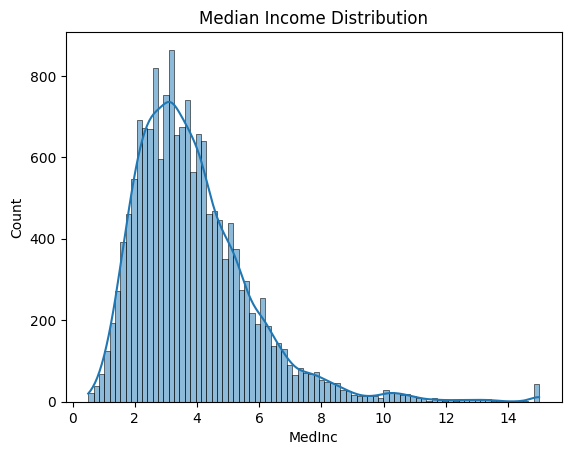

In [14]:
sns.histplot(X_train["MedInc"], kde=True)
plt.title("Median Income Distribution")
plt.show()

## Right-skewed

#
## Which Shape changing method is suitable here?

Here the Observation is:

- Some features had strong right skewness (skew > 1), Long right tails, Possible heteroscedasticity.
- So we needed a distribution-reshaping transformation.

Log transformation is suitable when:

- Data is strictly positive ✔

- Strong right skew ✔

- Long-tailed distribution ✔

- Multiplicative relationship suspected ✔

##
Why Not Square Root?

- Sqrt is weaker than log. It reduces skew, but less aggressively.

##
Why Not Reciprocal?

- Reciprocal Reverses order, Makes interpretation harder, Can distort relationships, Very aggressive transformation


# 6. Log Transformation (Shape First)

In [15]:
X_train_log = X_train.copy()
X_test_log = X_test.copy()

for col in skewed_features:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])

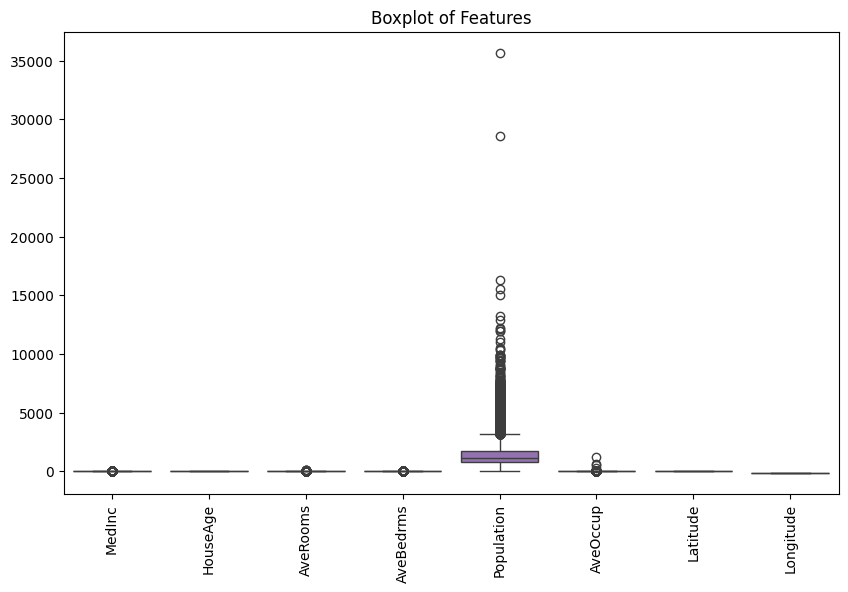

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data = X_train)
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()

In [17]:
# Outliers are to be checked on raw data only (NOT on the Log transformed data).
outlier_counts = {}

for col in X_train.columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    outlier_counts[col] = outliers

pd.Series(outlier_counts).sort_values(ascending=False)

,0
AveBedrms,1153
Population,955
AveOccup,582
MedInc,529
AveRooms,410
HouseAge,0
Latitude,0
Longitude,0


## Features with noticeable outliers:

Population → very large number of extreme values

AveOccup → several extreme points

## Interpretation from Outlier Counts (IQR Rule)

We computed number of values outside:

- Q1 − 1.5×IQR
- Q3 + 1.5×IQR

- These are not necessarily "bad" outliers.

- California Housing is Real-world socioeconomic data which is Naturally skewed, Heavy-tailed.

- Population: Some regions are highly dense. Not errors — just natural variation.

- AveOccup: Some block groups have unusual occupancy. Not necessarily data corruption.

There is a difference between extreme but valid values and erroneous outliers. This dataset mainly contains Heavy-tailed valid values, not errors.
###

### Should We Use Robust Scaling?
- Robust scaling is preferred when Few extreme values distort mean heavily and Dataset has pathological outliers.
- Here, Many values are flagged as IQR-outliers, but they are natural tail behavior, Linear regression performance improved with log + Z-score.

### So, Z-score is still reasonable.
###
### Why Log helped more than Robust Scaling?
- Because problem here is mainly due to Skewness and Long right tails NOT due to Rare extreme isolated errors.
- So, Log transformation addresses the main issue (skewness), Z-score addresses scale.

###

### Model specific:
- Z-score standardization was chosen because Linear Regression relies on gradient-based optimization, and centering features to mean 0 with unit variance improves numerical stability, convergence behavior, and coefficient comparability.

###

- Although Knn is not gradient-based, it is distance-based, and Z-score standardization ensures that all features contribute proportionally to Euclidean distance, preventing large-scale features from dominating the neighborhood calculation.


# 7. Scaling (Magnitude Next)

In [18]:
scaler = StandardScaler()

X_train_log_scaled = scaler.fit_transform(X_train_log) ## Compute mean (μ_train), standard deviation (σ_train) from training data
X_test_log_scaled = scaler.transform(X_test_log)       ## Use μ_train and σ_train and apply them to test data.

# 8. Linear Regression After Log Transformation + Scaling

In [19]:
lin_fe = LinearRegression()
lin_fe.fit(X_train_log_scaled, y_train)

y_pred_fe = lin_fe.predict(X_test_log_scaled)

rmse_fe = np.sqrt(mean_squared_error(y_test, y_pred_fe))
r2_fe = r2_score(y_test, y_pred_fe)

print("\nBaseline Linear RMSE:", rmse_base)
print("Baseline Linear R2:", r2_base)
print("\nFE Linear RMSE:", rmse_fe)
print("FE Linear R2:", r2_fe)


Baseline Linear RMSE: 0.7455813830127764
Baseline Linear R2: 0.5757877060324508

FE Linear RMSE: 0.7136160966676303
FE Linear R2: 0.6113824448098929


# 9. Knn After Log Transformation + Scaling

In [20]:
knn_scaled = KNeighborsRegressor(n_neighbors=5)
knn_scaled.fit(X_train_log_scaled, y_train)

y_pred_knn_scaled = knn_scaled.predict(X_test_log_scaled)

rmse_knn_scaled = np.sqrt(mean_squared_error(y_test, y_pred_knn_scaled))

print("Scaled KNN RMSE:", rmse_knn_scaled)

Scaled KNN RMSE: 0.6004926683309116


# 10. Data Leakage Demonstration
## Wrong Approach (Fit on Full Data) - Linear Regression

In [21]:
scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X)

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_scaled_wrong, y, test_size=0.2, random_state=42
)

lin_wrong = LinearRegression()
lin_wrong.fit(X_train_w, y_train_w)

rmse_wrong = np.sqrt(mean_squared_error(y_test_w, lin_wrong.predict(X_test_w)))

print("RMSE with Leakage:", rmse_wrong)

RMSE with Leakage: 0.7455813830127761


# 11. Final Comparison Table

In [22]:
results = pd.DataFrame({
    "Model": [
        "Linear - No FE",
        "Linear - Log + Scaling",
        "KNN - No Scaling",
        "KNN - Log + Scaling",
        "Linear - Leakage"
    ],
    "RMSE": [
        rmse_base,
        rmse_fe,
        rmse_knn_base,
        rmse_knn_scaled,
        rmse_wrong
    ]
})

results

,Model,RMSE
0,Linear - No FE,0.745581
1,Linear - Log + Scaling,0.713616
2,KNN - No Scaling,1.057678
3,KNN - Log + Scaling,0.600493
4,Linear - Leakage,0.745581


## Notice that leakage did not inflate performance here. That does NOT mean leakage is safe.

#

#

# Check few other aspects

## Discretization — cut() (Equal-Width)

In [28]:
df_disc = pd.DataFrame({
    "Income": [20, 25, 30, 35, 40, 45, 80, 90, 100]
})

df_disc["Income_cut"] = pd.cut(
    df_disc["Income"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

df_disc


,Income,Income_cut
0,20,Low
1,25,Low
2,30,Low
3,35,Low
4,40,Low
5,45,Low
6,80,High
7,90,High
8,100,High


## Discretization — qcut() (Equal-Frequency)

In [29]:
df_disc["Income_qcut"] = pd.qcut(
                                  df_disc["Income"],
                                  q=3,
                                  labels=["Low", "Medium", "High"]
                                  )

df_disc


,Income,Income_cut,Income_qcut
0,20,Low,Low
1,25,Low,Low
2,30,Low,Low
3,35,Low,Medium
4,40,Low,Medium
5,45,Low,Medium
6,80,High,High
7,90,High,High
8,100,High,High


In [30]:
df_disc["Income_qcut"] = pd.qcut(
                                  df_disc["Income"],
                                  q=4,
                                  labels=["Low", "Medium", "High", "Very High"]
                                  )

df_disc

,Income,Income_cut,Income_qcut
0,20,Low,Low
1,25,Low,Low
2,30,Low,Low
3,35,Low,Medium
4,40,Low,Medium
5,45,Low,High
6,80,High,High
7,90,High,Very High
8,100,High,Very High


## Binarization (Thresholding)

In [31]:
df_disc["High_Income_Flag"] = (df_disc["Income"] > 50).astype(int)
df_disc


,Income,Income_cut,Income_qcut,High_Income_Flag
0,20,Low,Low,0
1,25,Low,Low,0
2,30,Low,Low,0
3,35,Low,Medium,0
4,40,Low,Medium,0
5,45,Low,High,0
6,80,High,High,1
7,90,High,Very High,1
8,100,High,Very High,1


## Smoothing — 3-Month Moving Average

In [32]:
sales = pd.DataFrame({
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Sales": [100, 120, 90, 130, 110, 140]
})

sales["MA_3"] = sales["Sales"].rolling(window=3).mean()
sales


,Month,Sales,MA_3
0,Jan,100,NaN
1,Feb,120,NaN
2,Mar,90,103.333333
3,Apr,130,113.333333
4,May,110,110.000000
5,Jun,140,126.666667


# ---- END ----
#
#